# Gabarito — Tarefa 3: Redes Neurais
**Técnicas e Algoritmos em Ciência de Dados — FGV EMAp**

Este notebook é um gabarito de referência. Use-o para corrigir seu próprio trabalho após a entrega.

---

In [21]:
student_id = "XXXXXX"  # coloque seu identificador aqui

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)

# Funções Auxiliares

In [23]:
# ── Padronização ────────────────────────────────────────────────────────────
def standardize_from_train(X_train, X_val, X_test, return_params=False):
    """Padroniza usando apenas estatísticas do conjunto de treinamento."""
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma == 0] = 1          # evita divisão por zero

    X_tr = (X_train - mu) / sigma
    X_v  = (X_val   - mu) / sigma
    X_te = (X_test  - mu) / sigma

    if return_params:
        return X_tr, X_v, X_te, mu, sigma
    return X_tr, X_v, X_te


# ── Métricas ────────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def multiclass_metrics(y_true_onehot, y_prob, y_pred_indices):
    """
    Calcula AUROC (OvR macro), precisão, F1 e acurácia para classificação multiclasse.
    """
    true_indices = np.argmax(y_true_onehot, axis=1)

    auroc = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
    precision, _, f1, _ = precision_recall_fscore_support(
        true_indices, y_pred_indices, average='macro', zero_division=0
    )
    accuracy = accuracy_score(true_indices, y_pred_indices)

    print(f"AUROC: {auroc:.4f} | Precision: {precision:.4f} "
          f"| F1-score: {f1:.4f} | Accuracy: {accuracy:.4f}")
    return auroc, precision, f1, accuracy


# ── Codificação one-hot ─────────────────────────────────────────────────────
def one_hot(y_int, num_classes):
    """Converte vetor de inteiros (base-0 ou base-1) em matriz one-hot."""
    y_shifted = y_int - y_int.min()          # garante base-0
    Y = np.zeros((len(y_int), num_classes))
    Y[np.arange(len(y_int)), y_shifted.astype(int)] = 1
    return Y

# Funções de Ativação

In [24]:
class ActivationFunction:
    def __init__(self, fn, derivative=None):
        self.function   = fn
        self.derivative = derivative


def sigmoid(a):
    # Implementação numericamente estável
    return np.where(a >= 0,
                    1 / (1 + np.exp(-a)),
                    np.exp(a) / (1 + np.exp(a)))

def sigmoid_prime(a):
    s = sigmoid(a)
    return s * (1 - s)

sigmoid_activation = ActivationFunction(sigmoid, sigmoid_prime)


def softmax(a):
    # Subtrai o máximo por linha para estabilidade numérica
    shifted = a - a.max(axis=1, keepdims=True)
    exp_a   = np.exp(shifted)
    return exp_a / exp_a.sum(axis=1, keepdims=True)


def identity(a):
    return a

# Classe Base: MultilayerPerceptron

Contém forward pass, early stopping e o loop de treinamento. As subclasses implementam `backpropagation` e `compute_loss`.

In [25]:
class MultilayerPerceptron:
    """
    Rede neural densa (fully-connected) implementada do zero com NumPy.

    Os pesos de cada camada são armazenados em uma única matriz que inclui
    o viés na primeira coluna. A coluna de 1s é adicionada dinamicamente
    no forward pass (_add_ones), evitando vetores de bias separados.
    """

    def __init__(self, hidden_activation, output_activation,
                 input_size, hidden_sizes, output_size):
        """
        Parameters
        ----------
        hidden_activation : ActivationFunction
        output_activation : callable
        input_size        : int
        hidden_sizes      : list[int]  — comprimento = nº de camadas ocultas
        output_size       : int
        """
        self.hidden_activation       = hidden_activation.function
        self.hidden_activation_prime = hidden_activation.derivative
        self.output_activation       = output_activation
        self.input_size              = input_size
        self.hidden_sizes            = list(hidden_sizes)
        self.output_size             = output_size
        self.num_hidden_layers       = len(hidden_sizes)
        self._initialize_parameters()

    # ── Inicialização ────────────────────────────────────────────────────
    def _initialize_parameters(self):
        """
        Xavier/Glorot uniform initialization.
        self.parameters[i] tem forma (n_out, n_in + 1), onde a coluna 0
        corresponde ao bias.
        """
        sizes = [self.input_size] + self.hidden_sizes + [self.output_size]
        self.parameters = []
        for n_in, n_out in zip(sizes[:-1], sizes[1:]):
            limit = np.sqrt(6 / (n_in + n_out))
            W = np.random.uniform(-limit, limit, (n_out, n_in + 1))
            self.parameters.append(W)

    # ── Utilitários ──────────────────────────────────────────────────────
    @staticmethod
    def _add_ones(X):
        """Prefixa uma coluna de 1s para absorver o bias na multiplicação."""
        return np.column_stack((np.ones(X.shape[0]), X))

    # ── Forward pass (com cache para backprop) ───────────────────────────
    def _forward_pass(self, X):
        """
        Retorna: y_pred, Zs, As
          Zs[i] = entrada da camada i (com coluna de 1s)
          As[i] = pré-ativação da camada oculta i
        """
        z  = self._add_ones(X)
        Zs = [z]
        As = []

        for W in self.parameters[:-1]:        # camadas ocultas
            a = z @ W.T
            As.append(a)
            z = self._add_ones(self.hidden_activation(a))
            Zs.append(z)

        y_pred = self.output_activation(z @ self.parameters[-1].T)
        return y_pred, Zs, As

    # ── Forward pass rápido (sem cache) ─────────────────────────────────
    def _fast_forward(self, X):
        z = self._add_ones(X)
        for W in self.parameters[:-1]:
            z = self._add_ones(self.hidden_activation(z @ W.T))
        return self.output_activation(z @ self.parameters[-1].T)

    # ── Derivada da saída (MSE ou cross-entropy + softmax) ───────────────
    @staticmethod
    def _output_delta(y_pred, y_true):
        """dL/da_output — igual para MSE-linear e CE-softmax."""
        return y_pred - y_true

    # ── Treino ───────────────────────────────────────────────────────────
    def fit(self, X_train, y_train, X_val, y_val,
            update_method='mini_batch', batch_size=32,
            lr=0.01, epochs=50, patience=10):
        """
        Treina a rede com suporte a batch, SGD e mini-batch.
        Usa early stopping com restauração dos melhores pesos.

        Returns
        -------
        loss_train, loss_val : list  — histórico por época
        """
        if update_method == 'sgd':   batch_size = 1
        if update_method == 'batch': batch_size = X_train.shape[0]

        n = X_train.shape[0]
        loss_train, loss_val = [], []
        best_val   = float('inf')
        best_params = [W.copy() for W in self.parameters]
        no_improve  = 0

        for epoch in range(epochs):
            idx  = np.random.permutation(n)
            X_sh = X_train[idx]
            y_sh = y_train[idx]

            for start in range(0, n, batch_size):
                Xb = X_sh[start:start + batch_size]
                yb = y_sh[start:start + batch_size]
                grads = self.backpropagation(Xb, yb)
                for i, dW in enumerate(grads):
                    self.parameters[i] -= lr * dW

            y_hat_tr  = self._fast_forward(X_train)
            y_hat_val = self._fast_forward(X_val)
            loss_train.append(self.compute_loss(y_train, y_hat_tr))
            loss_val.append(  self.compute_loss(y_val,   y_hat_val))

            if loss_val[-1] < best_val:
                best_val    = loss_val[-1]
                best_params = [W.copy() for W in self.parameters]
                no_improve  = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

        self.parameters = best_params   # restaura melhores pesos
        return loss_train, loss_val

    # ── Métodos a implementar nas subclasses ─────────────────────────────
    def backpropagation(self, X, y):
        raise NotImplementedError

    def compute_loss(self, y_true, y_pred):
        raise NotImplementedError

---
# Parte 1 — Regressão com Redes Neurais (50%)

In [26]:
# ── Subclasse de Regressão ───────────────────────────────────────────────────
class MLPRegressor(MultilayerPerceptron):
    """
    MLP para regressão: camadas ocultas sigmoid, saída linear, loss = RMSE.
    """

    def __init__(self, input_size, hidden_layers, neurons_per_layer, output_size=1):
        """
        Parameters
        ----------
        input_size        : int
        hidden_layers     : int  — número de camadas ocultas
        neurons_per_layer : int  — mesmo nº de neurônios em todas as camadas ocultas
        """
        hidden_sizes = [neurons_per_layer] * hidden_layers
        super().__init__(
            hidden_activation=sigmoid_activation,
            output_activation=identity,
            input_size=input_size,
            hidden_sizes=hidden_sizes,
            output_size=output_size,
        )

    def backpropagation(self, X, y):
        n      = X.shape[0]
        y_enc  = y.reshape(-1, 1)
        y_pred, Zs, As = self._forward_pass(X)

        delta  = self._output_delta(y_pred, y_enc)        # (n, 1)
        grads  = [None] * len(self.parameters)
        grads[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            # Propaga o gradiente para trás (ignora a coluna de bias ao multiplicar)
            delta     = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            grads[l]  = delta.T @ Zs[l] / n

        return grads

    def predict(self, X):
        return self._fast_forward(X).ravel()

    def compute_loss(self, y_true, y_pred):
        y_p = y_pred.ravel() if y_pred.ndim > 1 else y_pred
        y_t = y_true.ravel() if y_true.ndim > 1 else y_true
        return rmse(y_t, y_p)

## 1.1 Pré-processamento

In [27]:
raw_reg = pd.read_csv('student_performance.csv')
display(raw_reg.head())
display(raw_reg.describe(include='all'))

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


In [28]:
perf = raw_reg.drop_duplicates().copy()

# Preenche NaNs em parent_education antes de mapear
perf['parent_education'] = perf['parent_education'].fillna('Others')

# Remove colunas que não devem ser features
perf.drop(columns=['student_id', 'passed'], inplace=True, errors='ignore')

# Mapeamento de categóricas
perf['gender']           = perf['gender'].map({'Male': 0, 'Female': 1})
perf['parent_education'] = perf['parent_education'].map(
    {'Bachelor': 0, 'High School': 1, 'Master': 2, 'PhD': 3, 'Others': 4}
)
perf['internet_access']  = perf['internet_access'].map({'Yes': 1, 'No': 0})
perf['extracurricular']  = perf['extracurricular'].map({'Yes': 1, 'No': 0})

perf.dropna(inplace=True)   # remove linhas com NaN residuais
display(perf.dtypes)
print(f"{len(perf)} amostras após limpeza")

gender                    int64
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education          int64
internet_access           int64
extracurricular           int64
previous_score            int64
final_score               int64
dtype: object

500 amostras após limpeza


In [29]:
X_reg = perf.iloc[:, :-1].values.astype(float)
y_reg = perf.iloc[:,  -1].values.astype(float)

# Divisão 70 / 15 / 15 sem estratificação (regressão)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_reg, y_reg, train_size=0.70, random_state=0)
X_v,  X_te,  y_v,  y_te  = train_test_split(X_tmp, y_tmp, train_size=0.50, random_state=0)

# Padronização usando apenas o treino
X_tr, X_v, X_te = standardize_from_train(X_tr, X_v, X_te)
print(f"Treino: {X_tr.shape} | Val: {X_v.shape} | Teste: {X_te.shape}")

Treino: (350, 8) | Val: (75, 8) | Teste: (75, 8)


## 1.2 Busca de Hiperparâmetros

In [30]:
regression_hidden_layers   = [1, 2, 3]
regression_neurons         = [100, 150, 250]
regression_update_methods  = ['batch', 'sgd', 'mini_batch']
regression_epochs          = 50
regression_lr              = 0.01
regression_patience        = 10

reg_records = []

for method in regression_update_methods:
    for n_layers in regression_hidden_layers:
        for n_neurons in regression_neurons:
            np.random.seed(0)
            model = MLPRegressor(
                input_size=X_tr.shape[1],
                hidden_layers=n_layers,
                neurons_per_layer=n_neurons,
            )
            tr_hist, val_hist = model.fit(
                X_tr, y_tr, X_v, y_v,
                update_method=method,
                lr=regression_lr,
                epochs=regression_epochs,
                patience=regression_patience,
            )
            val_rmse   = min(val_hist)
            best_epoch = val_hist.index(val_rmse) + 1
            reg_records.append({
                'update_method':     method,
                'hidden_layers':     n_layers,
                'neurons_per_layer': n_neurons,
                'validation_rmse':   val_rmse,
                'best_epoch':        best_epoch,
                'stopped_epoch':     len(val_hist),
            })
            print(f"{method:10s} | layers={n_layers} | neurons={n_neurons:3d} | val_rmse={val_rmse:.4f}")

regression_results = pd.DataFrame(reg_records).sort_values('validation_rmse').reset_index(drop=True)
display(regression_results)

batch      | layers=1 | neurons=100 | val_rmse=7.6209
batch      | layers=1 | neurons=150 | val_rmse=7.7945
batch      | layers=1 | neurons=250 | val_rmse=8.3298
batch      | layers=2 | neurons=100 | val_rmse=11.5982
batch      | layers=2 | neurons=150 | val_rmse=11.7967
batch      | layers=2 | neurons=250 | val_rmse=11.2428
batch      | layers=3 | neurons=100 | val_rmse=15.6071
batch      | layers=3 | neurons=150 | val_rmse=15.5639
batch      | layers=3 | neurons=250 | val_rmse=15.5754
sgd        | layers=1 | neurons=100 | val_rmse=8.0193
sgd        | layers=1 | neurons=150 | val_rmse=7.7858
sgd        | layers=1 | neurons=250 | val_rmse=7.8696
sgd        | layers=2 | neurons=100 | val_rmse=7.4516
sgd        | layers=2 | neurons=150 | val_rmse=7.6483
sgd        | layers=2 | neurons=250 | val_rmse=7.5344
sgd        | layers=3 | neurons=100 | val_rmse=7.3459
sgd        | layers=3 | neurons=150 | val_rmse=7.3550
sgd        | layers=3 | neurons=250 | val_rmse=7.2374
mini_batch | layers=1 

,update_method,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
0,sgd,3,250,7.237436,14,24
1,mini_batch,3,150,7.248257,24,34
2,mini_batch,3,100,7.259336,32,42
3,mini_batch,2,100,7.291742,12,22
4,mini_batch,3,250,7.317068,33,43
5,mini_batch,2,150,7.323628,17,27
6,mini_batch,2,250,7.325624,22,32
7,sgd,3,100,7.345893,15,25
8,sgd,3,150,7.354998,6,16
9,mini_batch,1,100,7.422915,14,24


## 1.3 Heatmaps de Validação

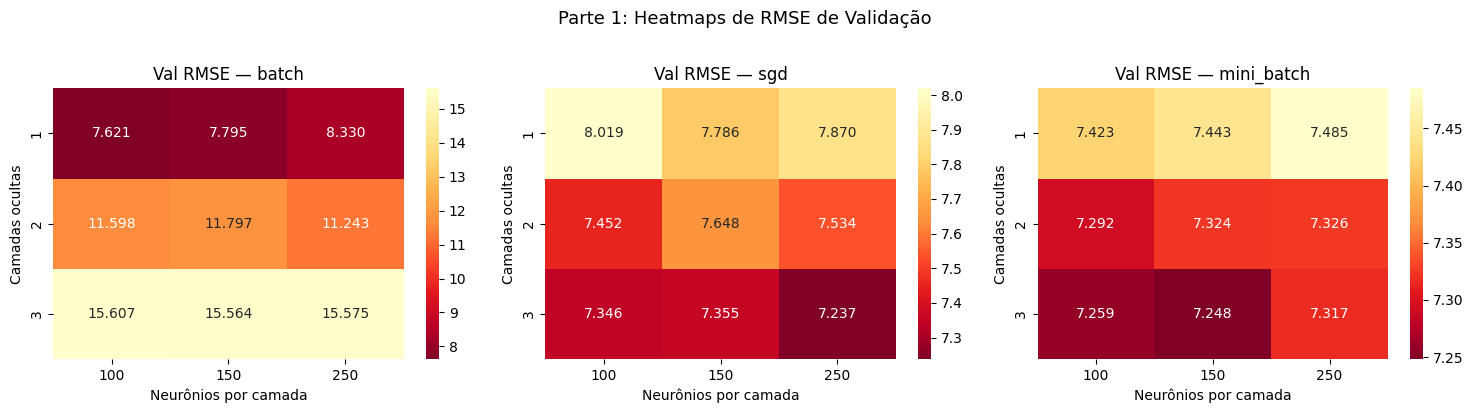

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method in zip(axes, regression_update_methods):
    subset = regression_results[regression_results['update_method'] == method]
    pivot  = subset.pivot(
        index='hidden_layers',
        columns='neurons_per_layer',
        values='validation_rmse',
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=ax)
    ax.set_title(f'Val RMSE — {method}')
    ax.set_xlabel('Neurônios por camada')
    ax.set_ylabel('Camadas ocultas')

plt.suptitle('Parte 1: Heatmaps de RMSE de Validação', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 1.4 Modelo Final e Avaliação no Teste

Melhor config: 3 camada(s) oculta(s), 250 neurônios, método=sgd


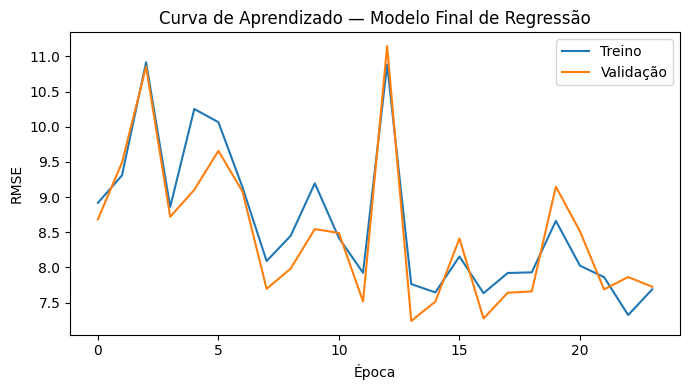

RMSE Validação: 7.2374
RMSE Teste:     8.0150


In [32]:
best_reg = regression_results.iloc[0]
best_hidden_layers = int(best_reg['hidden_layers'])
best_neurons       = int(best_reg['neurons_per_layer'])
best_method        = best_reg['update_method']

print(f"Melhor config: {best_hidden_layers} camada(s) oculta(s), "
      f"{best_neurons} neurônios, método={best_method}")

np.random.seed(0)
final_reg = MLPRegressor(
    input_size=X_tr.shape[1],
    hidden_layers=best_hidden_layers,
    neurons_per_layer=best_neurons,
)
tr_hist, val_hist = final_reg.fit(
    X_tr, y_tr, X_v, y_v,
    update_method=best_method,
    lr=regression_lr,
    epochs=regression_epochs,
    patience=regression_patience,
)

# Curvas de aprendizado
plt.figure(figsize=(7, 4))
plt.plot(tr_hist,  label='Treino')
plt.plot(val_hist, label='Validação')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('Curva de Aprendizado — Modelo Final de Regressão')
plt.legend()
plt.tight_layout()
plt.show()

best_regression_val_rmse  = rmse(y_v,  final_reg.predict(X_v))
best_regression_test_rmse = rmse(y_te, final_reg.predict(X_te))
print(f"RMSE Validação: {best_regression_val_rmse:.4f}")
print(f"RMSE Teste:     {best_regression_test_rmse:.4f}")

## 1.5 Baseline — Regressão Linear (do zero)

In [33]:
class ScratchLinearRegression:
    """
    Regressão linear treinada com gradiente descendente estocástico (SGD).
    """

    def __init__(self):
        self.w = None

    @staticmethod
    def _add_bias(X):
        return np.column_stack((np.ones(X.shape[0]), X))

    def fit(self, X, y, epochs=1000, lr=0.01):
        Phi = self._add_bias(X)
        n, d = Phi.shape
        self.w = np.zeros(d)

        for _ in range(epochs):
            idx = np.random.permutation(n)
            for j in idx:
                error   = y[j] - Phi[j] @ self.w
                self.w += lr * error * Phi[j]
        return self

    def predict(self, X):
        if self.w is None:
            raise RuntimeError("Chame fit() antes de predict().")
        return self._add_bias(X) @ self.w


np.random.seed(0)
lr_model = ScratchLinearRegression().fit(X_tr, y_tr, epochs=1000, lr=0.01)

rmse_lr_val  = rmse(y_v,  lr_model.predict(X_v))
rmse_lr_test = rmse(y_te, lr_model.predict(X_te))
print(f"Linear Regression — Val RMSE: {rmse_lr_val:.4f} | Teste RMSE: {rmse_lr_test:.4f}")

Linear Regression — Val RMSE: 7.6802 | Teste RMSE: 7.3058


## 1.6 Baseline TensorFlow

> **Por que o RMSE do TF pode ficar alto (~20)?**
>
> O modelo TF usa `SGD` com mini-batch de 32 e apenas 50 epochs, mesma configuração da sua NN NumPy. Com ativações sigmoid, os gradientes são muito pequenos nas camadas iniciais (*vanishing gradient*), e 50 epochs raramente são suficientes para convergência. A solução: o código abaixo aumenta o máximo de epochs para 500, mantendo early stopping.

In [34]:
import tensorflow as tf
tf.random.set_seed(0)

# ── NOTA: usamos 500 epochs para dar chance ao TF de convergir com sigmoid ──
TF_EPOCHS = 500

tf_reg = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr.shape[1],)),
    *[tf.keras.layers.Dense(best_neurons, activation='sigmoid')
      for _ in range(best_hidden_layers)],
    tf.keras.layers.Dense(1, activation='linear'),
])
tf_reg.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='mse',
)
tf_reg.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=TF_EPOCHS,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=regression_patience, restore_best_weights=True
    )],
    verbose=0,
)

tf_val_rmse  = rmse(y_v,  tf_reg.predict(X_v,  verbose=0).ravel())
tf_test_rmse = rmse(y_te, tf_reg.predict(X_te, verbose=0).ravel())
print(f"TF Baseline — Val RMSE: {tf_val_rmse:.4f} | Teste RMSE: {tf_test_rmse:.4f}")

TF Baseline — Val RMSE: 7.3921 | Teste RMSE: 7.8016


## 1.7 Tabela Comparativa Final

In [35]:
comparison_reg = pd.DataFrame([
    {'Modelo': 'NumPy MLP',              'RMSE Validação': best_regression_val_rmse,  'RMSE Teste': best_regression_test_rmse},
    {'Modelo': 'Regressão Linear',       'RMSE Validação': rmse_lr_val,               'RMSE Teste': rmse_lr_test},
    {'Modelo': 'TensorFlow (baseline)',  'RMSE Validação': tf_val_rmse,               'RMSE Teste': tf_test_rmse},
])
display(comparison_reg.style.format({'RMSE Validação': '{:.4f}', 'RMSE Teste': '{:.4f}'}))

,Modelo,RMSE Validação,RMSE Teste
0,NumPy MLP,7.2374,8.0150
1,Regressão Linear,7.6802,7.3058
2,TensorFlow (baseline),7.3921,7.8016


---
# Parte 2 — Classificação Multiclasse com Redes Neurais (50%)

In [36]:
# ── Subclasse de Classificação ───────────────────────────────────────────────
class MLPClassifier(MultilayerPerceptron):
    """
    MLP para classificação multiclasse: camadas ocultas sigmoid,
    saída softmax, loss = cross-entropy.
    A arquitetura aceita uma lista variável de tamanhos de camadas ocultas.
    """

    def __init__(self, input_size, hidden_sizes, output_size):
        """
        Parameters
        ----------
        hidden_sizes : list[int]  ex. [64, 128, 256]
        """
        super().__init__(
            hidden_activation=sigmoid_activation,
            output_activation=softmax,
            input_size=input_size,
            hidden_sizes=hidden_sizes,
            output_size=output_size,
        )

    def backpropagation(self, X, y):
        """
        Backpropagation para softmax + cross-entropy.
        O delta da camada de saída simplifica para (y_pred - y_true).
        """
        n = X.shape[0]
        y_target = y if y.ndim == 2 else one_hot(y, self.output_size)

        y_pred, Zs, As = self._forward_pass(X)

        delta = self._output_delta(y_pred, y_target)   # (n, K)
        grads = [None] * len(self.parameters)
        grads[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta    = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            grads[l] = delta.T @ Zs[l] / n

        return grads

    def predict_proba(self, X):
        return self._fast_forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def compute_loss(self, y_true, y_pred):
        y_t = y_true if y_true.ndim == 2 else one_hot(y_true, self.output_size)
        # Cross-entropy com clamp para evitar log(0)
        y_p = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return -np.sum(y_t * np.log(y_p)) / len(y_t)

## 2.1 Pré-processamento

In [37]:
raw_cls = pd.read_csv('dry_bean_database.csv', decimal=',')
display(raw_cls.head())
display(raw_cls.info())

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

None

In [38]:
beans = raw_cls.drop_duplicates().copy()

# Converte features numéricas armazenadas como string
for col in beans.columns[:-1]:
    beans[col] = pd.to_numeric(beans[col], errors='coerce')

beans.dropna(inplace=True)

# Mapeamento de classes
class_names = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
class_map   = {name: i for i, name in enumerate(class_names)}   # base-0
beans['Class'] = beans['Class'].map(class_map)

print(f"{len(beans)} amostras | distribuição de classes:")
display(beans['Class'].value_counts().sort_index())

13543 amostras | distribuição de classes:


Class
0    2027
1    1322
2     522
3    1630
4    1860
5    2636
6    3546
Name: count, dtype: int64

In [39]:
X_cls    = beans.iloc[:, :-1].values.astype(float)
y_cls_int = beans.iloc[:, -1].values.astype(int)     # inteiros 0..6
y_cls    = one_hot(y_cls_int, len(class_names))       # one-hot (N, 7)

# Divisão estratificada 70 / 15 / 15
X_tr_c, X_tmp_c, y_tr_c, y_tmp_c = train_test_split(
    X_cls, y_cls, train_size=0.70, random_state=0, stratify=y_cls_int
)
y_tmp_int = np.argmax(y_tmp_c, axis=1)
X_v_c, X_te_c, y_v_c, y_te_c = train_test_split(
    X_tmp_c, y_tmp_c, train_size=0.50, random_state=0, stratify=y_tmp_int
)

# Padronização
X_tr_c, X_v_c, X_te_c = standardize_from_train(X_tr_c, X_v_c, X_te_c)
print(f"Treino: {X_tr_c.shape} | Val: {X_v_c.shape} | Teste: {X_te_c.shape}")

Treino: (9480, 16) | Val: (2031, 16) | Teste: (2032, 16)


## 2.2 Busca de Hiperparâmetros

In [40]:
classification_layer_configs = [
    [64],
    [128, 64],
    [128, 128, 64],
]
classification_update_methods  = ['batch', 'sgd', 'mini_batch']
classification_epochs          = 1000
classification_lr              = 0.01
classification_patience        = 50

cls_records = []

for method in classification_update_methods:
    for arch in classification_layer_configs:
        np.random.seed(0)
        model = MLPClassifier(
            input_size=X_tr_c.shape[1],
            hidden_sizes=arch,
            output_size=len(class_names),
        )
        tr_hist, val_hist = model.fit(
            X_tr_c, y_tr_c, X_v_c, y_v_c,
            update_method=method,
            batch_size=256,
            lr=classification_lr,
            epochs=classification_epochs,
            patience=classification_patience,
        )
        val_loss   = min(val_hist)
        best_epoch = val_hist.index(val_loss) + 1
        cls_records.append({
            'update_method':  method,
            'architecture':   str(arch),
            'n_layers':       len(arch),
            'validation_loss': val_loss,
            'best_epoch':     best_epoch,
            'stopped_epoch':  len(val_hist),
        })
        print(f"{method:10s} | arch={arch} | val_loss={val_loss:.4f} (epoch {best_epoch})")

classification_results = (
    pd.DataFrame(cls_records)
    .sort_values('validation_loss')
    .reset_index(drop=True)
)
display(classification_results)

batch      | arch=[64] | val_loss=0.8721 (epoch 1000)
batch      | arch=[128, 64] | val_loss=1.4201 (epoch 1000)
batch      | arch=[128, 128, 64] | val_loss=1.8013 (epoch 1000)
sgd        | arch=[64] | val_loss=0.1865 (epoch 88)
sgd        | arch=[128, 64] | val_loss=0.1884 (epoch 70)
sgd        | arch=[128, 128, 64] | val_loss=0.1889 (epoch 108)
mini_batch | arch=[64] | val_loss=0.2188 (epoch 992)
mini_batch | arch=[128, 64] | val_loss=0.2178 (epoch 999)
mini_batch | arch=[128, 128, 64] | val_loss=0.2433 (epoch 988)


,update_method,architecture,n_layers,validation_loss,best_epoch,stopped_epoch
0,sgd,[64],1,0.186463,88,138
1,sgd,"[128, 64]",2,0.188415,70,120
2,sgd,"[128, 128, 64]",3,0.188889,108,158
3,mini_batch,"[128, 64]",2,0.217753,999,1000
4,mini_batch,[64],1,0.218772,992,1000
5,mini_batch,"[128, 128, 64]",3,0.243342,988,1000
6,batch,[64],1,0.872130,1000,1000
7,batch,"[128, 64]",2,1.420069,1000,1000
8,batch,"[128, 128, 64]",3,1.801347,1000,1000


## 2.3 Heatmaps de Validação

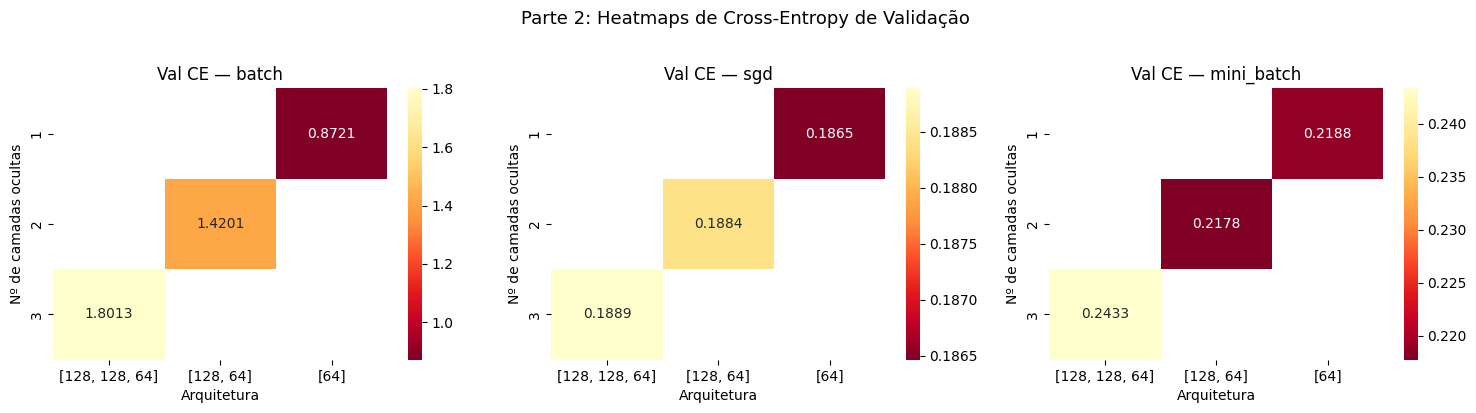

In [41]:
arch_labels = [str(a) for a in classification_layer_configs]
n_layers_labels = [len(a) for a in classification_layer_configs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method in zip(axes, classification_update_methods):
    subset = classification_results[classification_results['update_method'] == method].copy()
    pivot  = subset.pivot(
        index='n_layers',
        columns='architecture',
        values='validation_loss',
    )
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=ax)
    ax.set_title(f'Val CE — {method}')
    ax.set_xlabel('Arquitetura')
    ax.set_ylabel('Nº de camadas ocultas')

plt.suptitle('Parte 2: Heatmaps de Cross-Entropy de Validação', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2.4 Modelo Final e Avaliação no Teste

Melhor configuração: [64], método=sgd


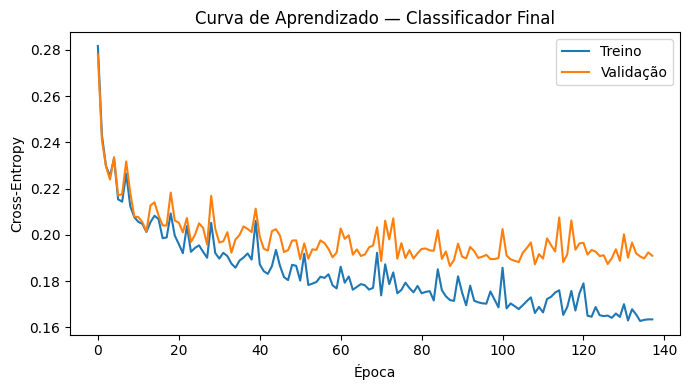

AUROC: 0.9957 | Precision: 0.9405 | F1-score: 0.9397 | Accuracy: 0.9281


In [42]:
best_cls = classification_results.iloc[0]
best_classification_layers = eval(best_cls['architecture'])
best_cls_method            = best_cls['update_method']
print(f"Melhor configuração: {best_classification_layers}, método={best_cls_method}")

np.random.seed(0)
final_cls = MLPClassifier(
    input_size=X_tr_c.shape[1],
    hidden_sizes=best_classification_layers,
    output_size=len(class_names),
)
tr_hist_c, val_hist_c = final_cls.fit(
    X_tr_c, y_tr_c, X_v_c, y_v_c,
    update_method=best_cls_method,
    batch_size=256,
    lr=classification_lr,
    epochs=classification_epochs,
    patience=classification_patience,
)

# Curvas
plt.figure(figsize=(7, 4))
plt.plot(tr_hist_c,  label='Treino')
plt.plot(val_hist_c, label='Validação')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy')
plt.title('Curva de Aprendizado — Classificador Final')
plt.legend()
plt.tight_layout()
plt.show()

# Métricas no teste
y_prob_np  = final_cls.predict_proba(X_te_c)
y_pred_np  = final_cls.predict(X_te_c)
y_true_idx = np.argmax(y_te_c, axis=1)

np_auroc, np_prec, np_f1, np_acc = multiclass_metrics(y_te_c, y_prob_np, y_pred_np)

## 2.5 Baseline — Regressão Logística OvR (do zero)

In [43]:
class ScratchLogisticRegression:
    """
    Regressão Logística One-vs-Rest (OvR) para classificação multiclasse.
    Cada classificador binário é treinado com gradiente descendente estocástico.
    """

    def __init__(self):
        self.weights  = None
        self.classes_ = None

    @staticmethod
    def _sigmoid(z):
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

    @staticmethod
    def _add_bias(X):
        return np.column_stack((np.ones(X.shape[0]), X))

    def fit(self, X, y_onehot, epochs=500, lr=0.01):
        """
        Parameters
        ----------
        X        : (N, d)
        y_onehot : (N, K)  — matriz one-hot
        """
        Phi = self._add_bias(X)
        n, d = Phi.shape
        K    = y_onehot.shape[1]
        self.weights  = np.zeros((K, d))
        self.classes_ = K

        for k in range(K):
            y_k = y_onehot[:, k]
            w   = np.zeros(d)
            for _ in range(epochs):
                idx = np.random.permutation(n)
                for j in idx:
                    p   = self._sigmoid(Phi[j] @ w)
                    w  += lr * (y_k[j] - p) * Phi[j]
            self.weights[k] = w
        return self

    def predict_proba(self, X):
        logits = self._add_bias(X) @ self.weights.T   # (N, K)
        probs  = self._sigmoid(logits)
        # Normaliza para obter distribuição de probabilidade
        row_sum = probs.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        return probs / row_sum

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


np.random.seed(0)
lr_cls = ScratchLogisticRegression().fit(
    X_tr_c, y_tr_c, epochs=300, lr=0.01
)

lr_prob = lr_cls.predict_proba(X_te_c)
lr_pred = lr_cls.predict(X_te_c)
print("Logistic Regression OvR:")
lr_auroc, lr_prec, lr_f1, lr_acc = multiclass_metrics(y_te_c, lr_prob, lr_pred)

Logistic Regression OvR:
AUROC: 0.9942 | Precision: 0.9303 | F1-score: 0.9297 | Accuracy: 0.9163


## 2.6 Baseline TensorFlow

In [44]:
import tensorflow as tf
tf.random.set_seed(0)

tf_cls = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr_c.shape[1],)),
    *[tf.keras.layers.Dense(u, activation='sigmoid')
      for u in best_classification_layers],
    tf.keras.layers.Dense(y_tr_c.shape[1], activation='softmax'),
])
tf_cls.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
)
tf_cls.fit(
    X_tr_c, y_tr_c,
    validation_data=(X_v_c, y_v_c),
    epochs=classification_epochs,
    batch_size=256,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=classification_patience,
        restore_best_weights=True,
    )],
    verbose=0,
)

tf_prob = tf_cls.predict(X_te_c, verbose=0)
tf_pred = np.argmax(tf_prob, axis=1)
print("TensorFlow baseline:")
tf_auroc, tf_prec, tf_f1, tf_acc = multiclass_metrics(y_te_c, tf_prob, tf_pred)

TensorFlow baseline:
AUROC: 0.9947 | Precision: 0.9289 | F1-score: 0.9284 | Accuracy: 0.9144


## 2.7 Tabela e Barplots Comparativos

In [45]:
comparison_cls = pd.DataFrame([
    {'Modelo': 'NumPy MLP',              'AUROC': np_auroc,  'Precisão': np_prec,  'F1': np_f1,  'Acurácia': np_acc},
    {'Modelo': 'Logistic Reg. (OvR)',    'AUROC': lr_auroc,  'Precisão': lr_prec,  'F1': lr_f1,  'Acurácia': lr_acc},
    {'Modelo': 'TensorFlow (baseline)',  'AUROC': tf_auroc,  'Precisão': tf_prec,  'F1': tf_f1,  'Acurácia': tf_acc},
])
display(comparison_cls.style.format({
    'AUROC': '{:.4f}', 'Precisão': '{:.4f}', 'F1': '{:.4f}', 'Acurácia': '{:.4f}'
}))

,Modelo,AUROC,Precisão,F1,Acurácia
0,NumPy MLP,0.9957,0.9405,0.9397,0.9281
1,Logistic Reg. (OvR),0.9942,0.9303,0.9297,0.9163
2,TensorFlow (baseline),0.9947,0.9289,0.9284,0.9144


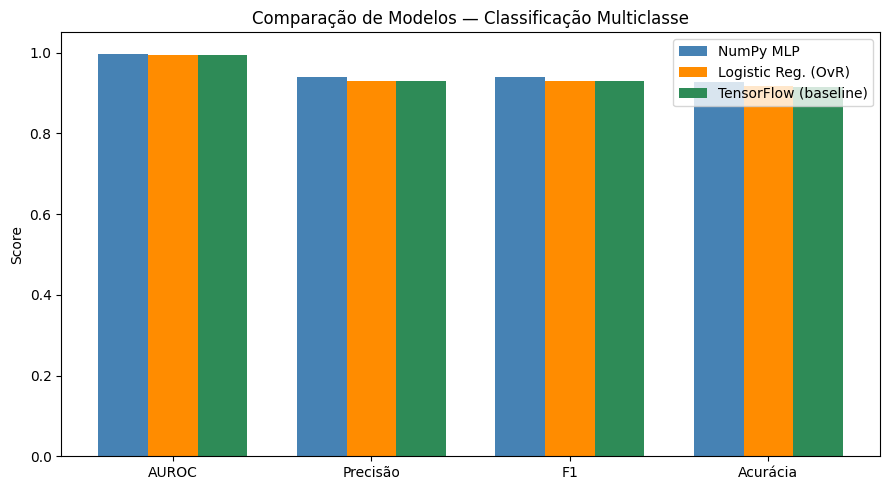

In [46]:
metrics = ['AUROC', 'Precisão', 'F1', 'Acurácia']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (_, row) in enumerate(comparison_cls.iterrows()):
    ax.bar(x + i * width,
           [row[m] for m in metrics],
           width, label=row['Modelo'], color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Classificação Multiclasse')
ax.legend()
plt.tight_layout()
plt.show()

---
# Resumo dos Bugs Encontrados no Template

| # | Local | Bug | Correção |
|---|-------|-----|----------|
| 1 | Classificação — loop de resultados | `sort_values('validation_rmse')` mas a coluna se chama `'validation_loss'` | Use `'validation_loss'` |
| 2 | `MultilayerPerceptronClassification.backpropagation` | Referencia `self.sizes[2]` (atributo da Parte 1) — na Parte 2 o atributo é `self.output_size` | Substitua por `self.output_size` |
| 3 | TF Regressão | RMSE alto (~20) porque sigmoid + 50 epochs + SGD causa *vanishing gradient* e não converge | Aumente `epochs` para 300-500; ou use `relu` na baseline TF |
| 4 | `ScratchLinearRegression.predict` | `if self.parameters.all()` lança `ValueError` em arrays NumPy | Use `if self.w is not None` |
| 5 | `ScratchLinearRegression.fit` | Treinada com `epochs=1` (padrão) — não converge | Use `epochs=1000` na chamada |
| 6 | `multiclass_metrics` | Usa `sklearn.metrics.auc` que espera arrays 1-D pré-calculados, não é OvR | Use `roc_auc_score(..., multi_class='ovr')` |
| 7 | Parte 2 — split | Não aplica padronização nos conjuntos de classificação | Adicione `standardize_from_train` após o split |
| 8 | `softmax` | `exp_a.sum(axis=1)` sem `keepdims=True` → erro de broadcast | Use `keepdims=True` |

---
**Dica profissional:** em produção, use `np.clip(y_pred, 1e-12, 1-1e-12)` antes de `np.log` para evitar `log(0) = -inf` na cross-entropy.